# **Data Loading**


Load data from web URL

In [11]:
import pandas as pd
import os

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.to_csv('titanic.csv', index=False)
print("File got downloaded.")
print("Location:", os.getcwd())
print("Full path:", os.path.abspath('titanic.csv'))

File got downloaded.
Location: /content
Full path: /content/titanic.csv


Load data from device


In [6]:
from google.colab import files

print("Please upload your titanic.csv file:")
uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(filename)
    print(f"Successfully loaded: {filename}")
    print(f"Shape: {df.shape}")

Please upload your titanic.csv file:


Saving titanic.csv to titanic (1).csv
Successfully loaded: titanic (1).csv
Shape: (891, 12)


## **Exploratory Data Analysis (EDA)**

In [7]:
 print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### Data Type Inspection

In [8]:
dtype_df = pd.DataFrame({
    'Feature': df.columns,
    'Type': df.dtypes.values,
    'Nulls': df.isnull().sum().values})
print(dtype_df.to_string(index=False))

    Feature    Type  Nulls
PassengerId   int64      0
   Survived   int64      0
     Pclass   int64      0
       Name  object      0
        Sex  object      0
        Age float64    177
      SibSp   int64      0
      Parch   int64      0
     Ticket  object      0
       Fare float64      0
      Cabin  object    687
   Embarked  object      2


### Summary Statistics

In [9]:
statistic = df.describe().round(2)
print(statistic)

       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


### Missing Value Assessment

In [10]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Feature': missing_values.index, 'Missing': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("No missing values found")

 Feature  Missing  Percentage
     Age      177       19.87
   Cabin      687       77.10
Embarked        2        0.22


### Unique Value Counts

In [12]:
for col in df.columns:
    if df[col].dtype == 'object' or df[col].nunique() < 10:
        n = df[col].nunique()
        vals = df[col].dropna().unique()[:5] if n > 10 else df[col].dropna().unique()
        #vals = list(vals)
        print(f"{col}: {n} unique -> {vals}")

Survived: 2 unique -> [0 1]
Pclass: 3 unique -> [3 1 2]
Name: 891 unique -> ['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry']
Sex: 2 unique -> ['male' 'female']
SibSp: 7 unique -> [1 0 3 4 2 5 8]
Parch: 7 unique -> [0 1 2 5 3 4 6]
Ticket: 681 unique -> ['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450']
Cabin: 147 unique -> ['C85' 'C123' 'E46' 'G6' 'C103']
Embarked: 3 unique -> ['S' 'C' 'Q']


# **Data Visualization**

### **Categorical Variable Visualization**

Categorical Visualization of raw data

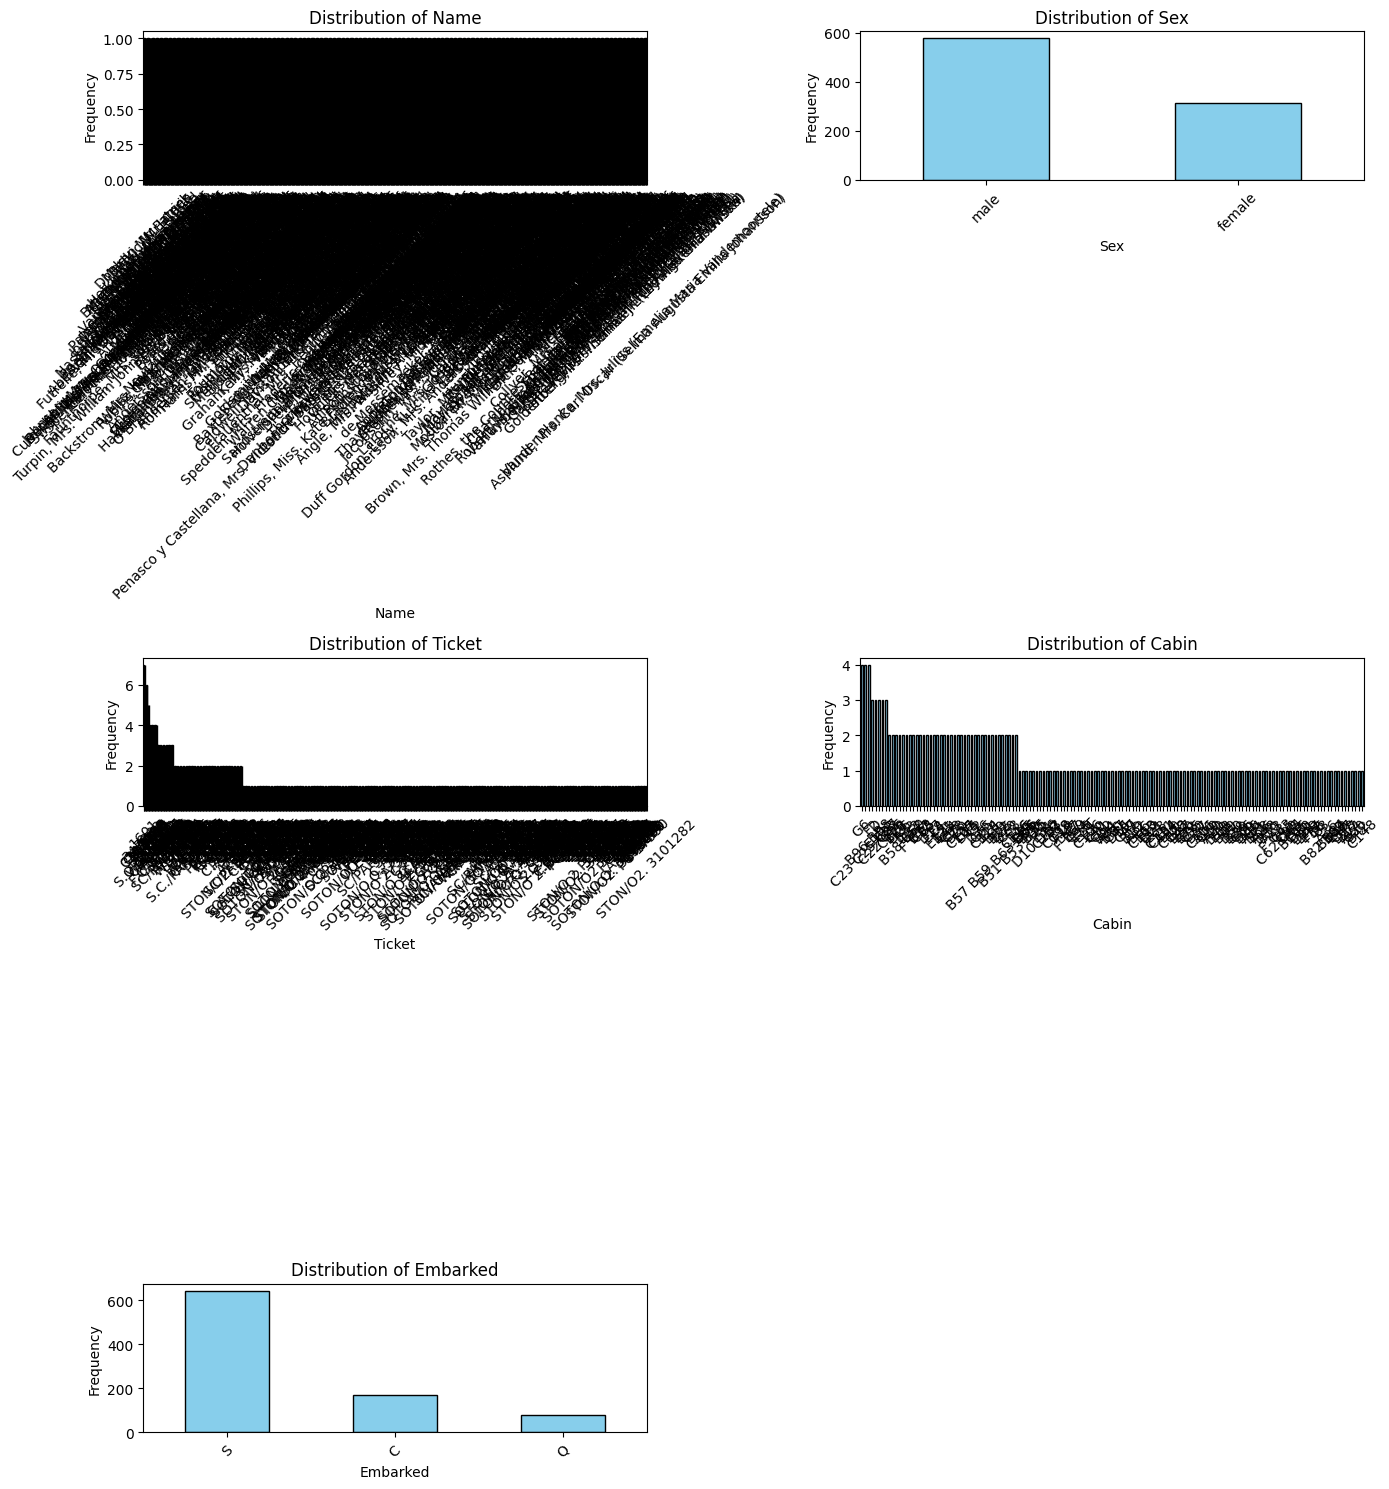

In [13]:
import matplotlib.pyplot as plt
categorical_cols = df.select_dtypes(include=['object']).columns
n_cols = 2
n_rows = (len(categorical_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Categorical Visualization Of Some Entities

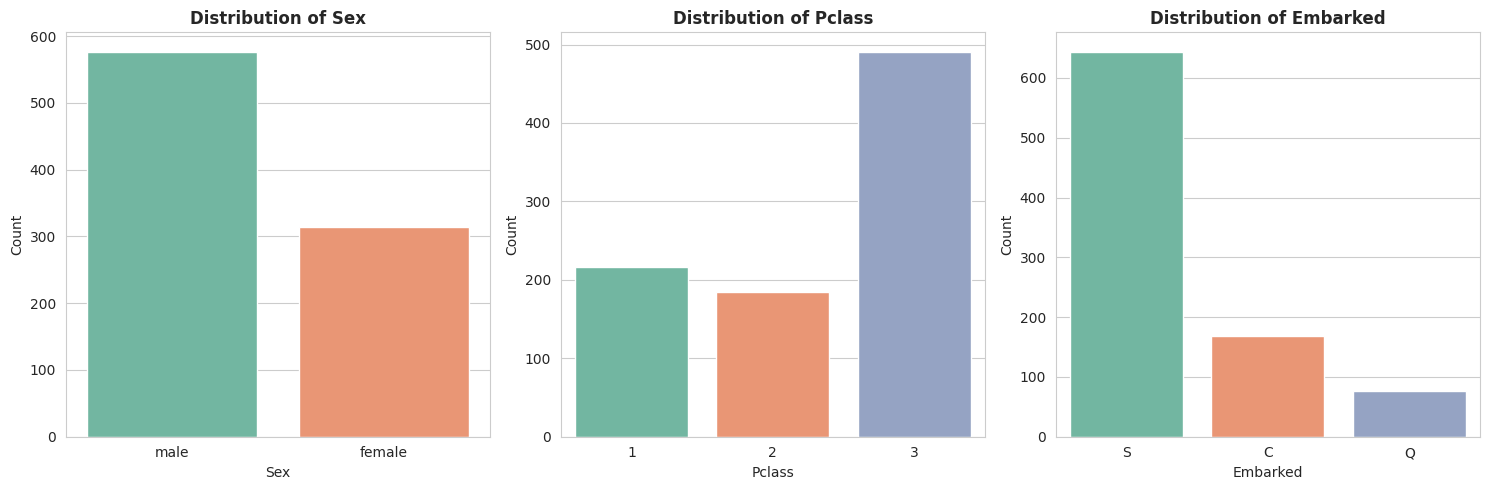


Skipped columns (too many unique values for bar plot):
  - Name: 891 unique values
  - Ticket: 681 unique values
  - Cabin: 147 unique values


In [14]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns

sns.set_style("whitegrid")

cat_cols = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nSkipped columns (too many unique values for bar plot):")
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() > 10:
        print(f"  - {col}: {df[col].nunique()} unique values")

Ticket Visualization

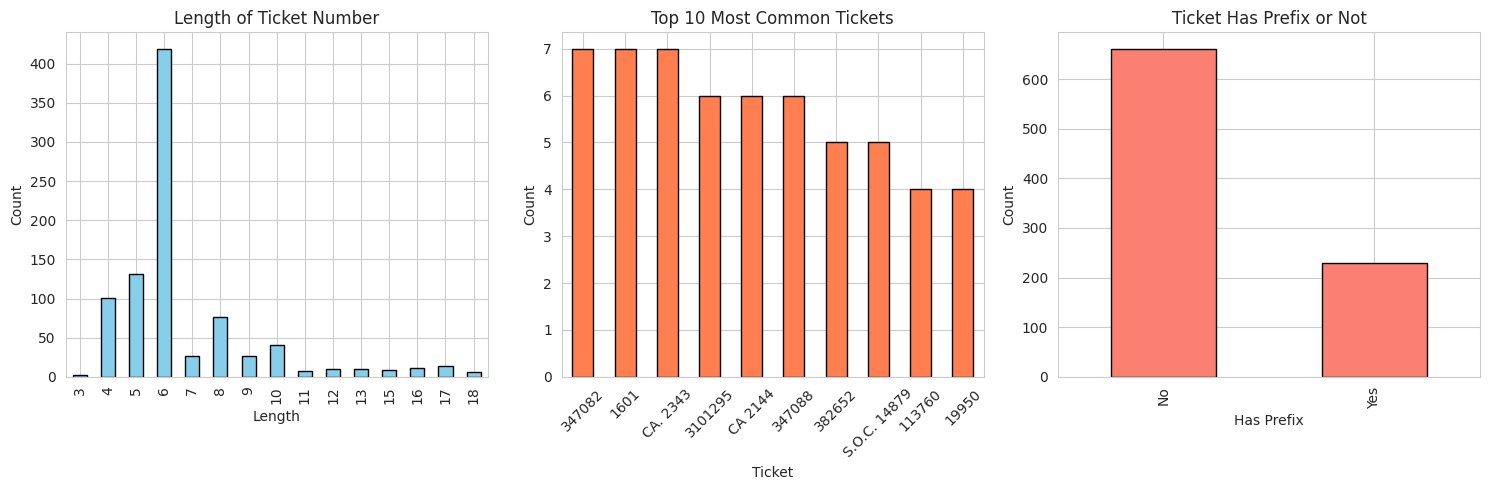

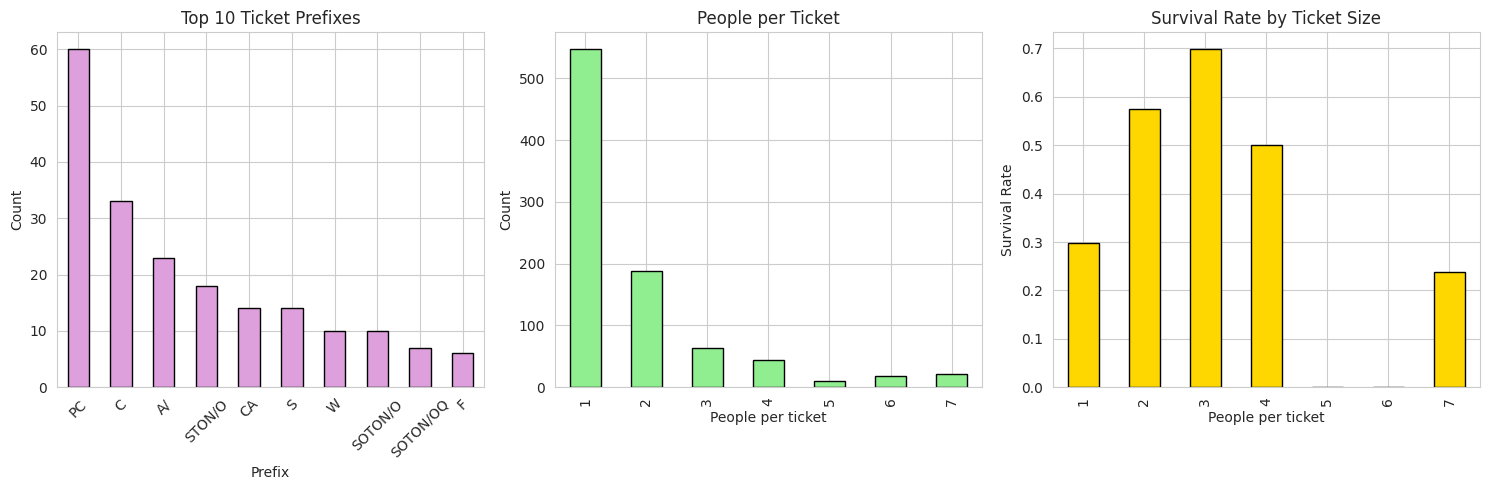

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df['Ticket_Group_Size'] = df.groupby('Ticket')['Ticket'].transform('count')
df['Ticket_Length'] = df['Ticket'].astype(str).str.len()
df['Prefix'] = df['Ticket'].str.extract('([A-Za-z/]+)')
df['Has_Prefix'] = df['Ticket'].str.contains('[A-Za-z]', na=False).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['Ticket_Length'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Length of Ticket Number')
axes[0].set_xlabel('Length')
axes[0].set_ylabel('Count')

df['Ticket'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 10 Most Common Tickets')
axes[1].set_xlabel('Ticket')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

df['Has_Prefix'].value_counts().plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Ticket Has Prefix or Not')
axes[2].set_xlabel('Has Prefix')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['Prefix'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='plum', edgecolor='black')
axes[0].set_title('Top 10 Ticket Prefixes')
axes[0].set_xlabel('Prefix')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['Ticket_Group_Size'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('People per Ticket')
axes[1].set_xlabel('People per ticket')
axes[1].set_ylabel('Count')

df.groupby('Ticket_Group_Size')['Survived'].mean().plot(kind='bar', ax=axes[2], color='gold', edgecolor='black')
axes[2].set_title('Survival Rate by Ticket Size')
axes[2].set_xlabel('People per ticket')
axes[2].set_ylabel('Survival Rate')
plt.tight_layout()
plt.show()

Name Visualization

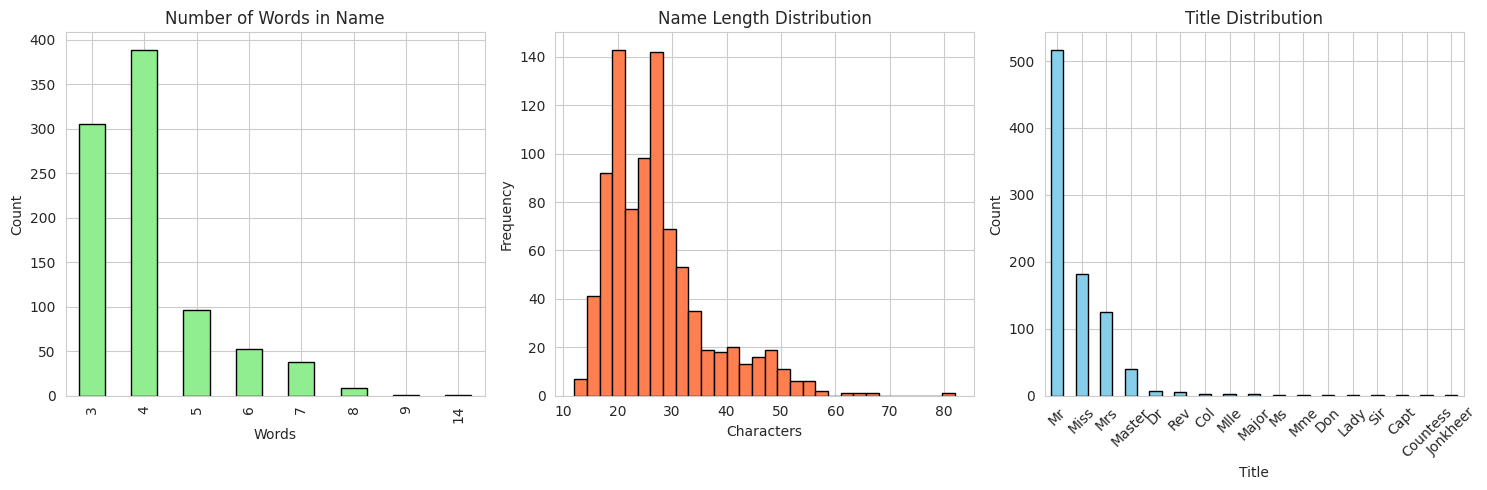

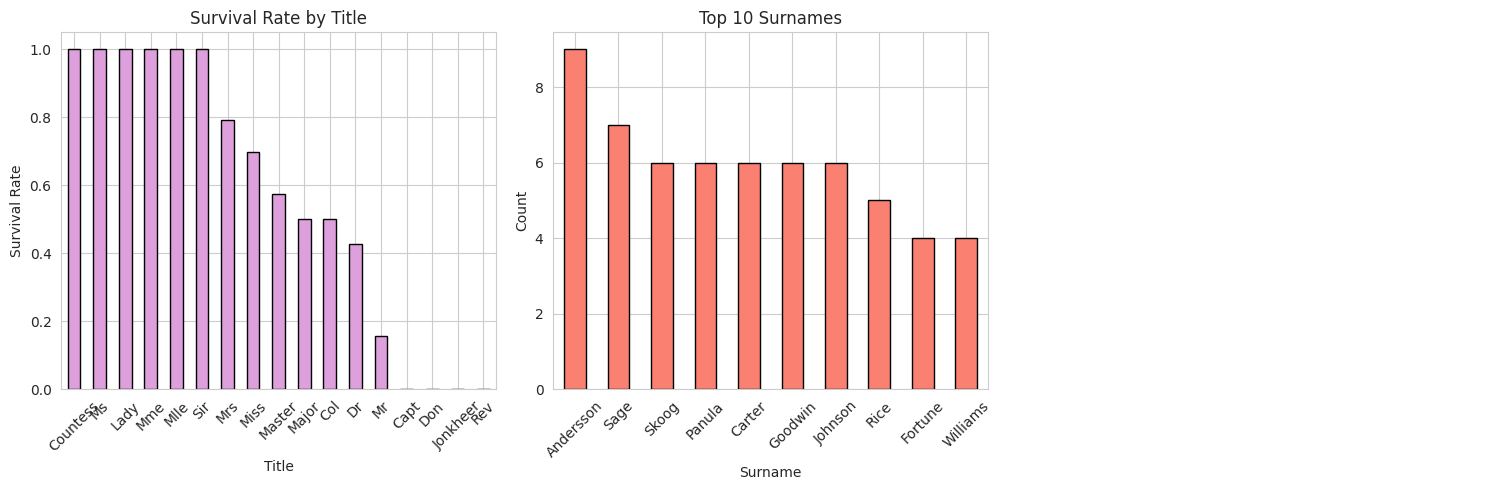

In [16]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Name_Length'] = df['Name'].str.len()
df['Name_Words'] = df['Name'].str.split().str.len()
df['Surname'] = df['Name'].str.split(',').str[0]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['Name_Words'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Number of Words in Name')
axes[0].set_xlabel('Words')
axes[0].set_ylabel('Count')

df['Name_Length'].hist(bins=30, ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Name Length Distribution')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

df['Title'].value_counts().plot(kind='bar', ax=axes[2], color='skyblue', edgecolor='black')
axes[2].set_title('Title Distribution')
axes[2].set_xlabel('Title')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df.groupby('Title')['Survived'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='plum', edgecolor='black')
axes[0].set_title('Survival Rate by Title')
axes[0].set_xlabel('Title')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=45)

df['Surname'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Top 10 Surnames')
axes[1].set_xlabel('Surname')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

axes[2].axis('off')
plt.tight_layout()
plt.show()

Cabin Visualization

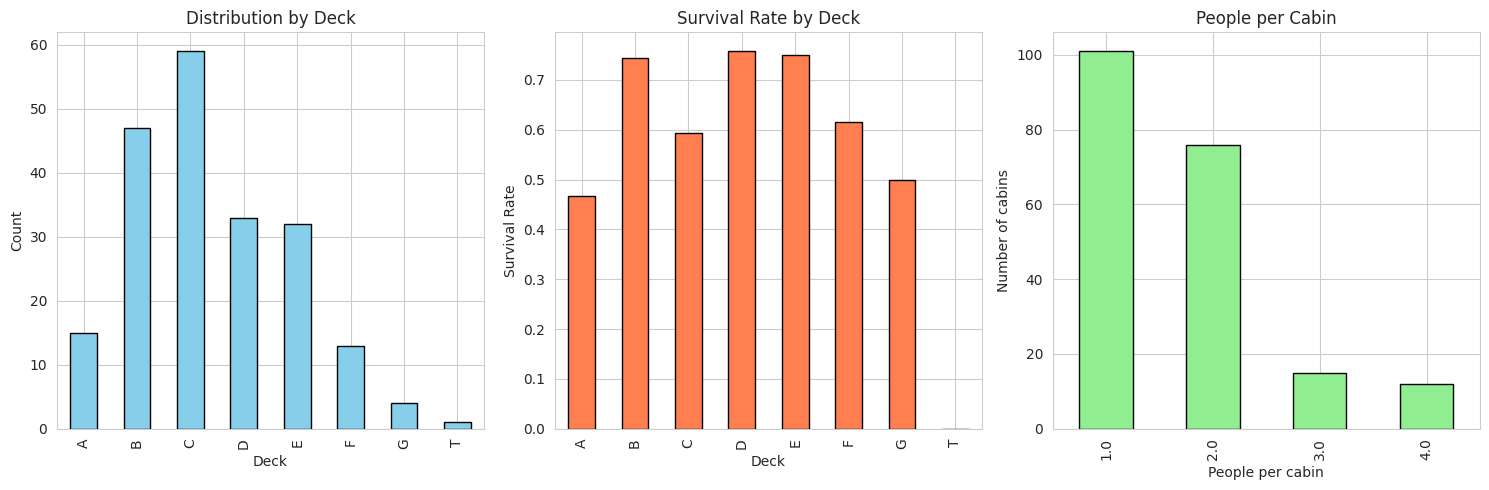

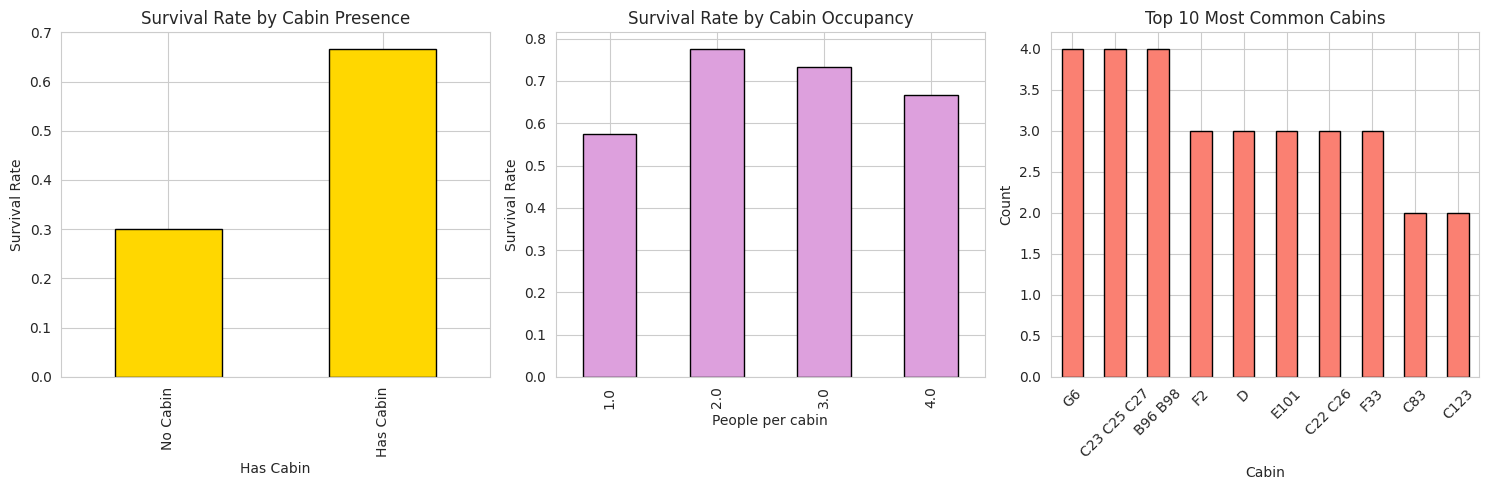

In [17]:
import matplotlib.pyplot as plt

df['Deck'] = df['Cabin'].dropna().str[0]
df['Cabin_Shared'] = df.groupby('Cabin')['Cabin'].transform('count')
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['Deck'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution by Deck')
axes[0].set_xlabel('Deck')
axes[0].set_ylabel('Count')

df.groupby('Deck')['Survived'].mean().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Survival Rate by Deck')
axes[1].set_xlabel('Deck')
axes[1].set_ylabel('Survival Rate')

df[df['Cabin_Shared'] > 0]['Cabin_Shared'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='lightgreen', edgecolor='black')
axes[2].set_title('People per Cabin')
axes[2].set_xlabel('People per cabin')
axes[2].set_ylabel('Number of cabins')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df.groupby('Has_Cabin')['Survived'].mean().plot(kind='bar', ax=axes[0], color='gold', edgecolor='black')
axes[0].set_title('Survival Rate by Cabin Presence')
axes[0].set_xlabel('Has Cabin')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(['No Cabin', 'Has Cabin'])

df.groupby('Cabin_Shared')['Survived'].mean().plot(kind='bar', ax=axes[1], color='plum', edgecolor='black')
axes[1].set_title('Survival Rate by Cabin Occupancy')
axes[1].set_xlabel('People per cabin')
axes[1].set_ylabel('Survival Rate')

df['Cabin'].value_counts().head(10).plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Top 10 Most Common Cabins')
axes[2].set_xlabel('Cabin')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### **Numerical Variable Visualization**

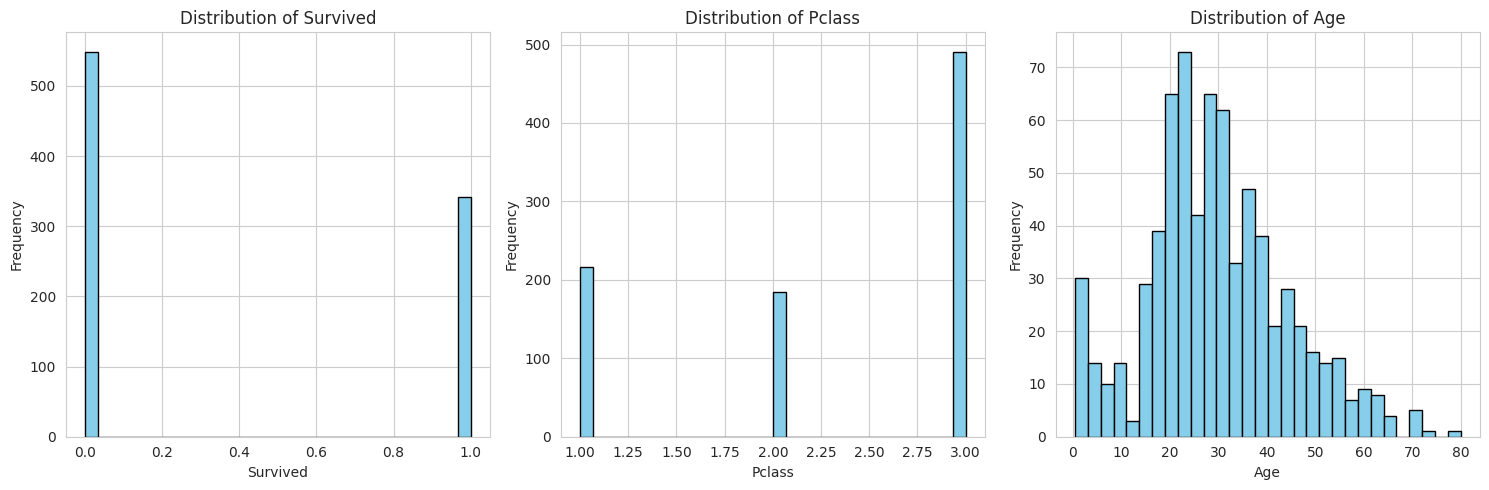

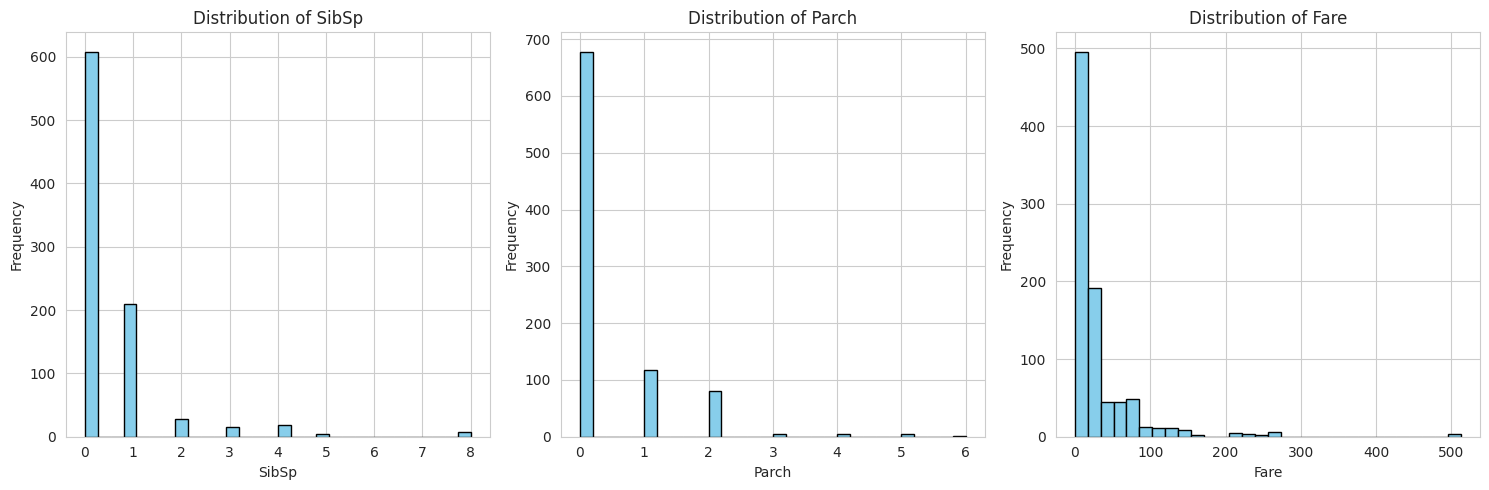

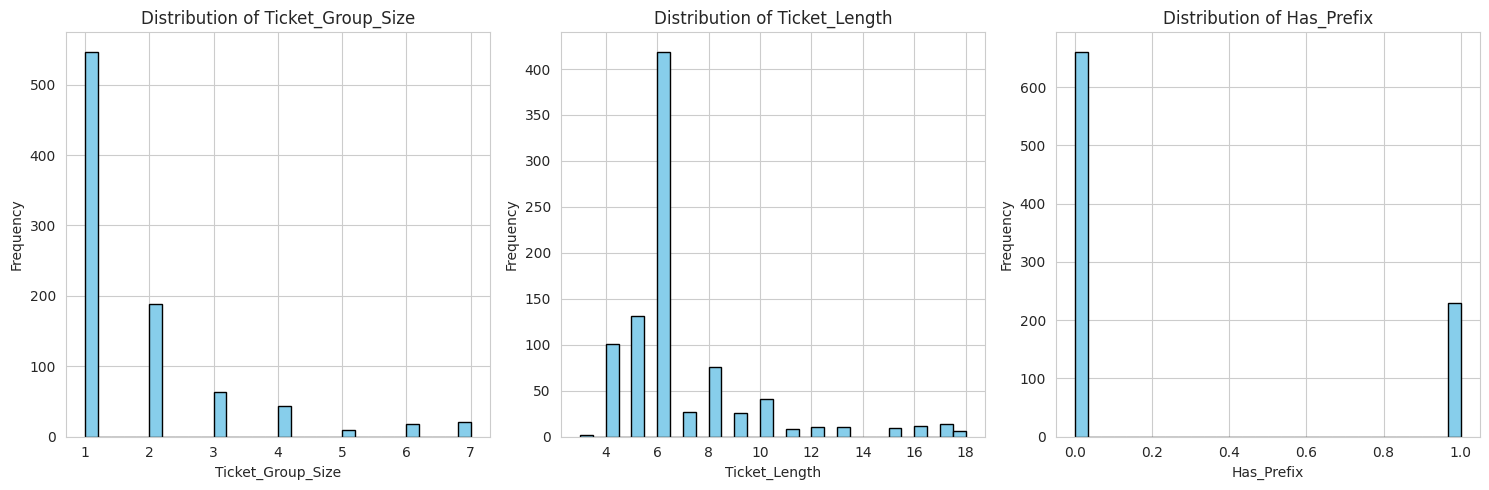

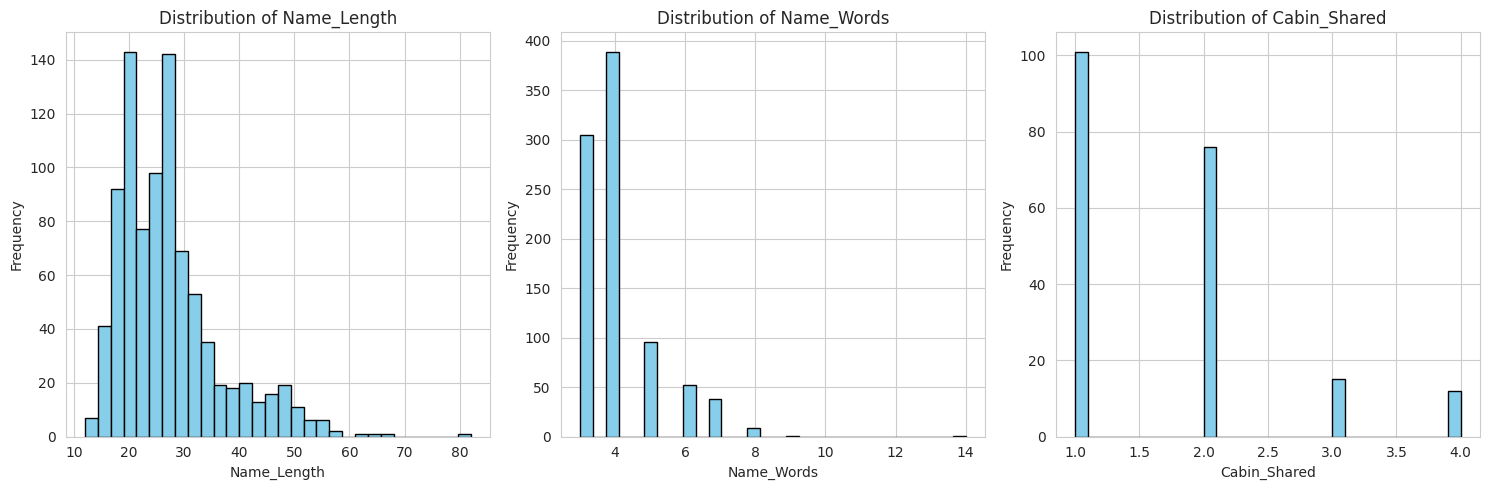

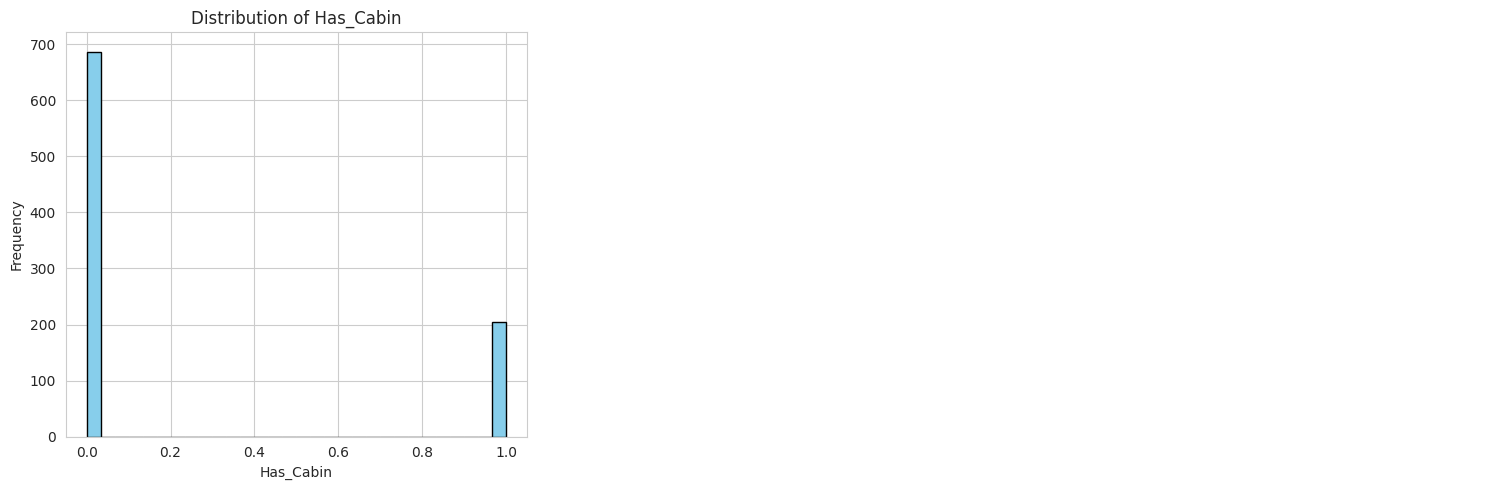

In [18]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != 'PassengerId']

for i in range(0, len(num_cols), 3):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for j in range(3):
        if i + j < len(num_cols):
            col = num_cols[i + j]
            df[col].dropna().hist(bins=30, ax=axes[j], color='skyblue', edgecolor='black')
            axes[j].set_title(f'Distribution of {col}')
            axes[j].set_xlabel(col)
            axes[j].set_ylabel('Frequency')
        else:
            axes[j].axis('off')
    plt.tight_layout()
    plt.show()

Corelations Between Numeric Entities



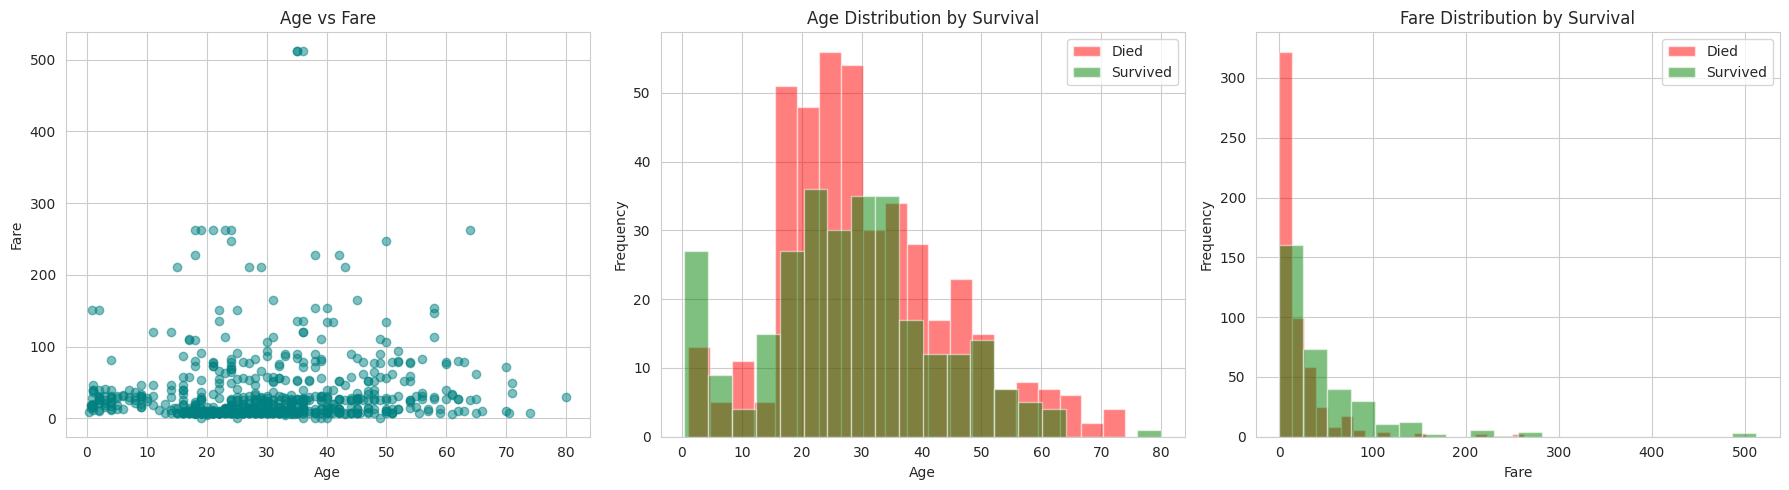

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Age vs Fare (scatter)
axes[0].scatter(df['Age'], df['Fare'], alpha=0.5, color='teal')
axes[0].set_title('Age vs Fare')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Fare')

# Plot 2: Age Distribution by Survival (histogram)
axes[1].hist(df[df['Survived']==0]['Age'].dropna(), bins=20, alpha=0.5, label='Died', color='red')
axes[1].hist(df[df['Survived']==1]['Age'].dropna(), bins=20, alpha=0.5, label='Survived', color='green')
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3: Fare Distribution by Survival (histogram)
axes[2].hist(df[df['Survived']==0]['Fare'], bins=20, alpha=0.5, label='Died', color='red')
axes[2].hist(df[df['Survived']==1]['Fare'], bins=20, alpha=0.5, label='Survived', color='green')
axes[2].set_title('Fare Distribution by Survival')
axes[2].set_xlabel('Fare')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()

### **Correlation Heatmap**

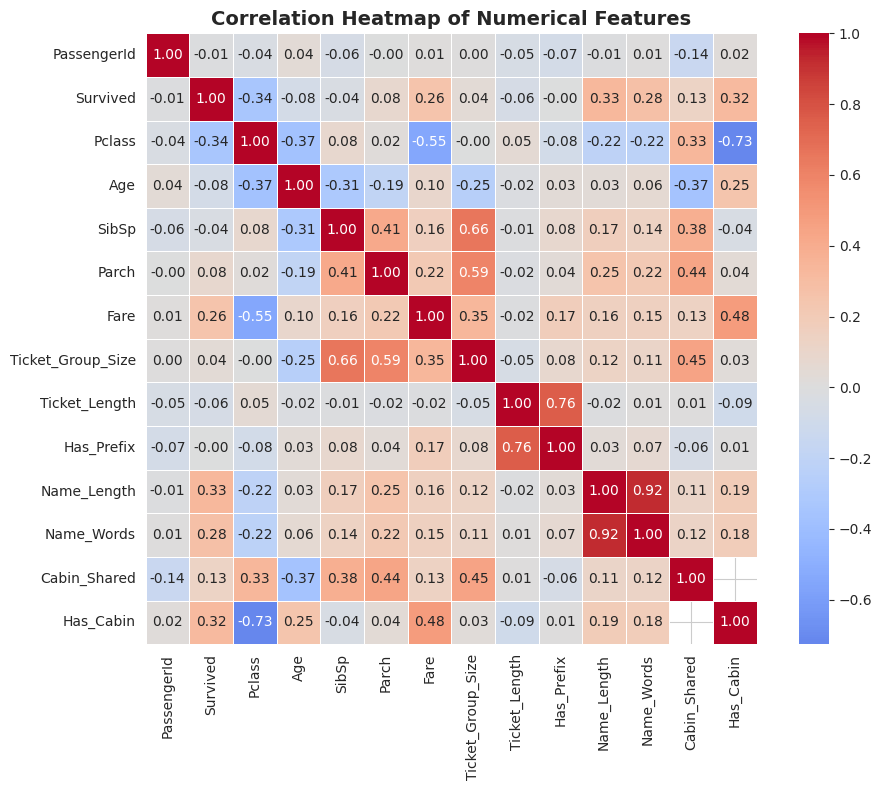

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()